# ST 4035 - Assignment 1

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.utils import resample

#### Load Dataset

In [2]:
# Load the dataset
train = pd.read_csv("data/employee_train.csv")
test = pd.read_csv("data/employee_test.csv")

#### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeID                3500 non-null   object
 1   Age                       3500 non-null   int64 
 2   Gender                    3500 non-null   object
 3   Department                3500 non-null   object
 4   JobRole                   3500 non-null   object
 5   YearsAtCompany            3500 non-null   int64 
 6   MonthlyIncome             3500 non-null   int64 
 7   DistanceFromHome          3500 non-null   int64 
 8   NumCompaniesWorked        3500 non-null   int64 
 9   OverTime                  3500 non-null   object
 10  TrainingTimesLastYear     3500 non-null   int64 
 11  WorkLifeBalance           3500 non-null   int64 
 12  JobSatisfaction           3500 non-null   int64 
 13  EnvironmentSatisfaction   3500 non-null   int64 
 14  RelationshipSatisfaction

In [4]:
# Summary Statistics
train.describe()

,Age,YearsAtCompany,MonthlyIncome,DistanceFromHome,NumCompaniesWorked,TrainingTimesLastYear,WorkLifeBalance,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,JobInvolvement,PerformanceRating,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,39.083429,19.682571,10552.667429,15.174286,4.527143,3.024286,2.512571,2.509429,2.519143,2.494286,2.496857,3.499714,7.395714,8.412571,0.019714
std,12.343188,11.813333,5552.778238,8.298512,2.861099,1.991618,1.124241,1.121472,1.129221,1.133663,1.121252,0.500071,4.598760,5.205529,0.139037
min,18.000000,0.000000,1021.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000
25%,28.000000,10.000000,5732.000000,8.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,3.000000,3.000000,4.000000,0.000000
50%,39.000000,19.000000,10494.500000,15.000000,4.000000,3.000000,3.000000,2.500000,2.000000,2.000000,2.000000,3.000000,7.000000,8.000000,0.000000
75%,50.000000,30.000000,15392.750000,22.000000,7.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,11.000000,13.000000,0.000000
max,60.000000,40.000000,19984.000000,29.000000,9.000000,6.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,15.000000,17.000000,1.000000


In [5]:
# Class Distribution
train['Attrition'].value_counts() # Highly imbalance

Attrition
0    3431
1      69
Name: count, dtype: int64

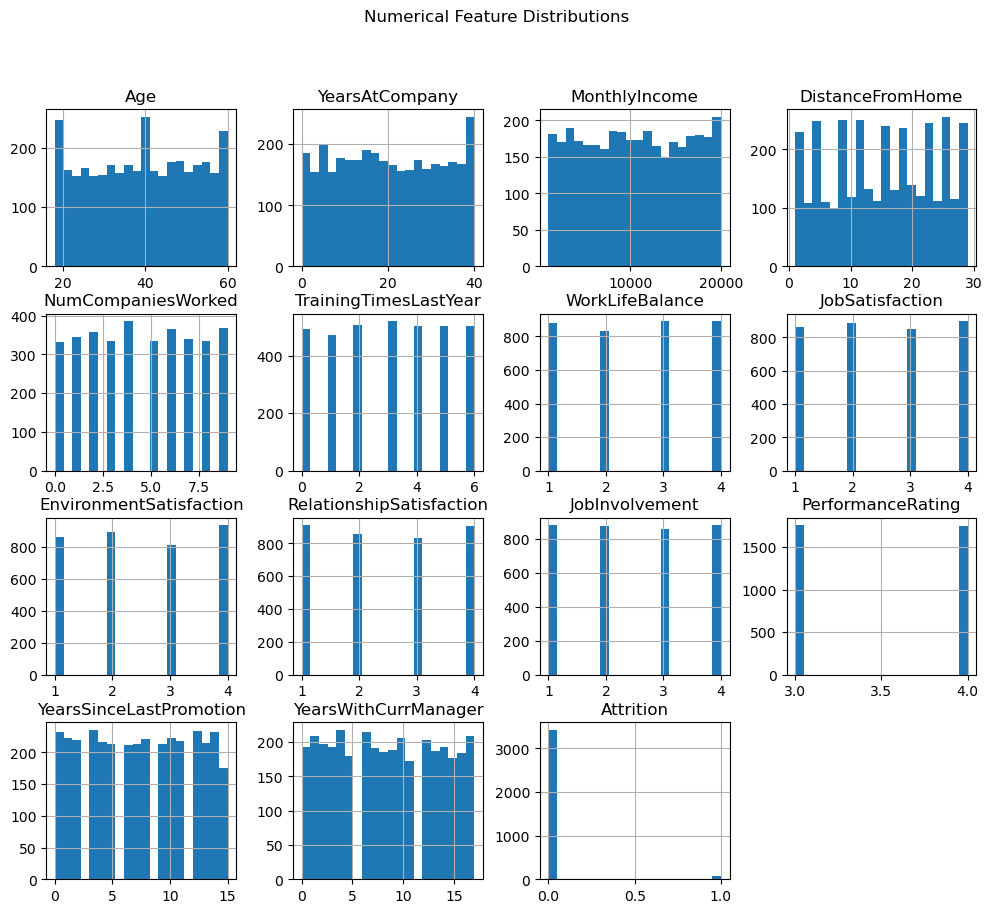

In [6]:
num_cols = train.select_dtypes(include=np.number).columns

train[num_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

Most continuous variables like Age, YearsAtCompany, MonthlyIncome, and DistanceFromHome appear fairly evenly distributed without strong skewness. This suggests no extreme concentration in specific ranges.
NumCompaniesWorked and TrainingTimesLastYear also show relatively balanced distributions, indicating employees have varied past experience and training exposure.
Variables such as WorkLifeBalance, JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, and JobInvolvement are discrete (1–4 scale) and appear roughly evenly spread, with no single category dominating strongly.
PerformanceRating is highly imbalanced, mostly concentrated at ratings 3 and 4, which suggests limited variability in performance evaluations.
YearsSinceLastPromotion and YearsWithCurrManager show a moderate spread, indicating diversity in employee tenure and managerial relationships.

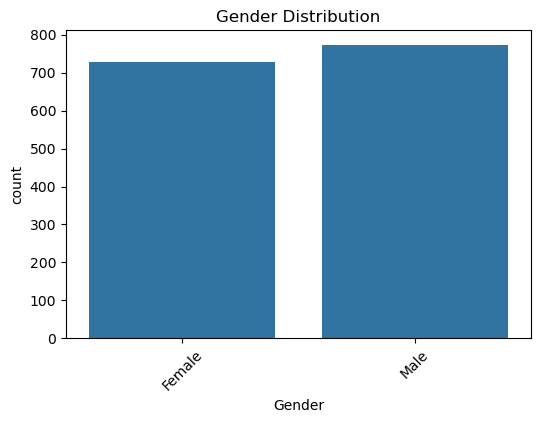

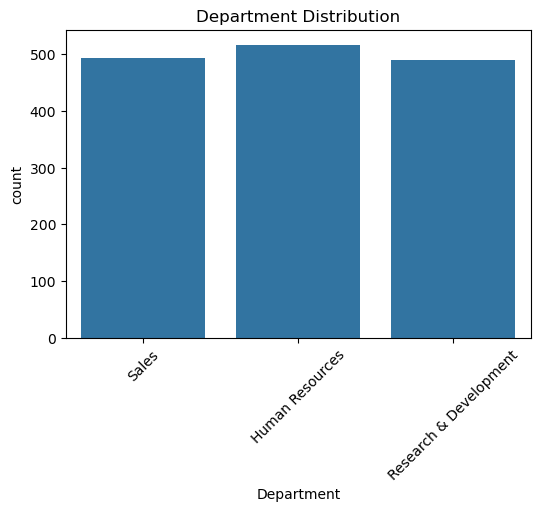

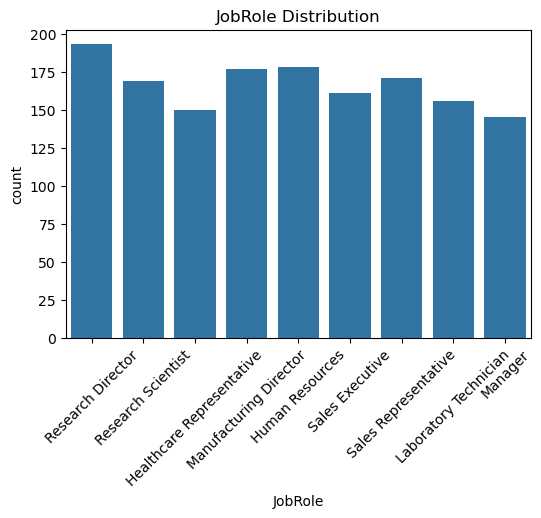

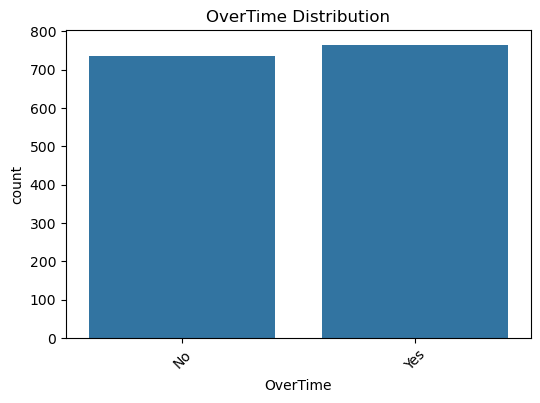

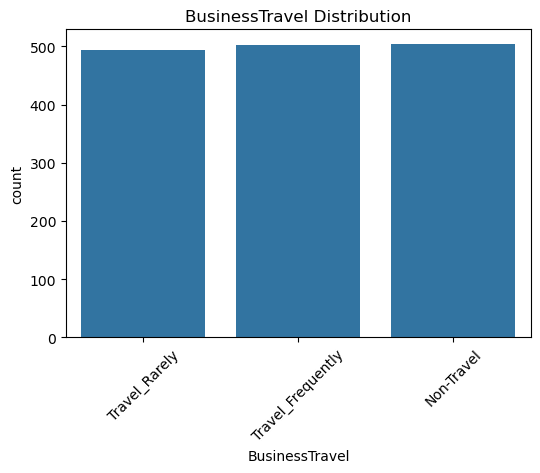

In [7]:
cat_cols = train.select_dtypes(include='object').columns.drop('EmployeeID')

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=test)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

The categorical variables generally display uniform distributions across categories, with minimal variation, except for Job Role, which shows a more uneven distribution.

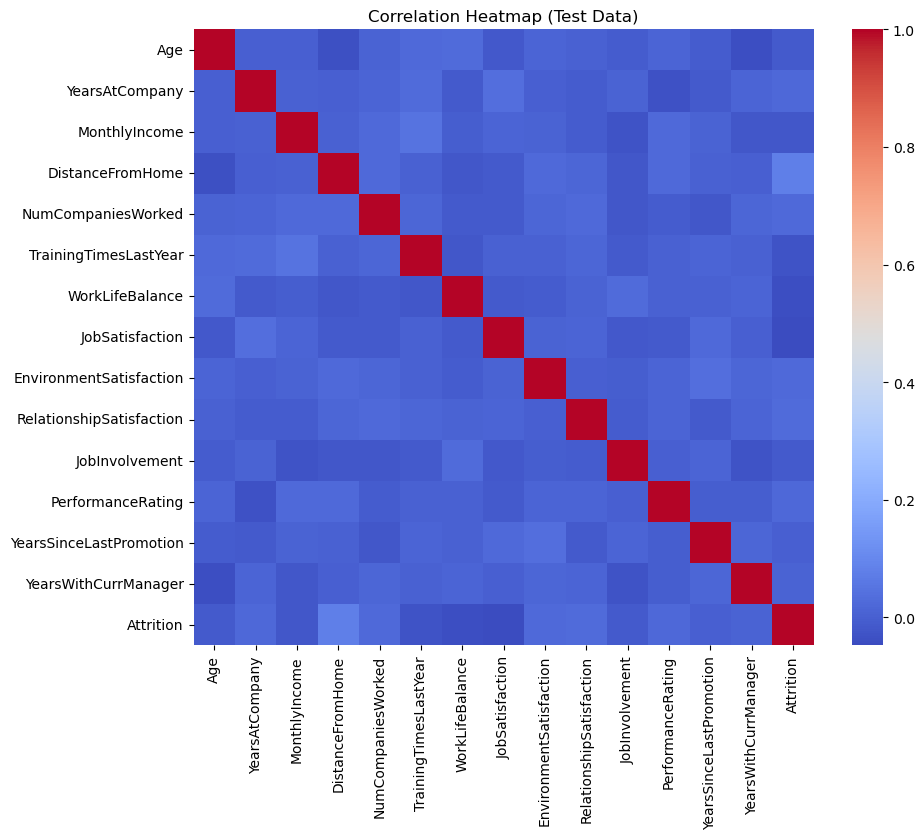

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Test Data)")
plt.show()

Most feature pairs show very weak or near-zero correlations (values close to 0), indicating that the variables are largely independent of each other.

In [9]:
train.isnull().sum()

EmployeeID                  0
Age                         0
Gender                      0
Department                  0
JobRole                     0
YearsAtCompany              0
MonthlyIncome               0
DistanceFromHome            0
NumCompaniesWorked          0
OverTime                    0
TrainingTimesLastYear       0
WorkLifeBalance             0
JobSatisfaction             0
EnvironmentSatisfaction     0
RelationshipSatisfaction    0
JobInvolvement              0
PerformanceRating           0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
BusinessTravel              0
Attrition                   0
dtype: int64

#### Data Preprocessing

In [10]:
# Drop ID
train.drop('EmployeeID', axis=1, inplace=True) # Just an identifier - No predictive meaning

In [11]:
test_ids = test['EmployeeID']
test.drop('EmployeeID', axis=1, inplace=True)

In [12]:
# One-hot Encoding
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

In [13]:
y = train['Attrition'] #Response Variable

In [14]:
train = train.drop('Attrition', axis=1) # Predictors

In [15]:
train, test = train.align(test, join='left', axis=1, fill_value=0)  # Same columns in the same order

#### Feature Engineering

In [16]:
for df in [train, test]:
    # Most of the other variables are measured in terms of years
    df['IncomePerYear'] = df['MonthlyIncome'] * 12  

    # Similar satisfaction variables into one feature to reduce multicollinearity and simplify the model.
    df['TotalSatisfaction'] = ( 
        df['JobSatisfaction'] +
        df['EnvironmentSatisfaction'] +
        df['RelationshipSatisfaction']
    ) / 3

# Drop redundant columns
drop_cols = [
    'MonthlyIncome',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'PerformanceRating'
]

train.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols, axis=1, inplace=True)

#### Train-Test Split

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    train, y, test_size=0.2, random_state=42, stratify=y
)

#### Handling Class Imbalance

In [18]:
# Resampling
train_combined = pd.concat([X_train, y_train], axis=1)

majority = train_combined[train_combined.Attrition == 0]
minority = train_combined[train_combined.Attrition == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

train_resampled = pd.concat([majority, minority_upsampled])

# Shuffle
train_resampled = train_resampled.sample(frac=1, random_state=42)

X_train_res = train_resampled.drop('Attrition', axis=1)
y_train_res = train_resampled['Attrition']

#### Scaling

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res) # Learn scaling from training data + apply it
X_val_scaled = scaler.transform(X_val) # Apply the same scaling learned from training data

# Before the split - Scaler would use information from validation data. Makes validation performance over-optimistic

#### Feature Selection & Model Training (initial)

In [20]:
logreg = LogisticRegression(
    penalty=None,
    max_iter=1000,
)

In [21]:
# Select best features using forward sequential feature selection with Logistic Regression
sfs = SequentialFeatureSelector(
    logreg,
    n_features_to_select=10,
    direction="forward",
    scoring="f1", # Optimize F1-score for better balance between precision and recall
    cv=5, # 5-Fold cross-validation
    n_jobs=-1
)

sfs.fit(X_train_scaled, y_train_res)  

SequentialFeatureSelector(estimator=LogisticRegression(max_iter=1000,
                                                       penalty=None),
                          n_features_to_select=10, n_jobs=-1, scoring='f1')

In [22]:
# keeping only the selected subset of features
X_train_sfs = sfs.transform(X_train_scaled)
X_val_sfs = sfs.transform(X_val_scaled)

In [23]:
logreg.fit(X_train_sfs, y_train_res)

LogisticRegression(max_iter=1000, penalty=None)

#### Threshold Tuning

In [24]:
probs = logreg.predict_proba(X_val_sfs)[:, 1] # Get predicted probabilities for the positive class (Attrition = 1)

# Initialize variables to store the best threshold and corresponding F1 score
best_t = 0
best_f1 = 0

# Iterate over a range of threshold values to find the optimal cutoff
for t in np.linspace(0.1, 0.6, 200):
    y_pred = (probs > t).astype(int) # Convert probabilities to binary predictions based on threshold
    score = f1_score(y_val, y_pred) # Compute F1 score for current threshold

    if score > best_f1: # Update best threshold if current F1 score is higher
        best_f1 = score
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.6
Best F1: 0.1276595744680851


In [25]:
y_pred_best = (probs > best_t).astype(int) # Convert probabilities to binary predictions based on the observed best threshold

#### Evaluation

In [26]:
print("Accuracy:", accuracy_score(y_val, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_best))
print("Classification Report:\n", classification_report(y_val, y_pred_best, zero_division=0))

Accuracy: 0.8242857142857143
Confusion Matrix:
 [[568 118]
 [  5   9]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.83      0.90       686
           1       0.07      0.64      0.13        14

    accuracy                           0.82       700
   macro avg       0.53      0.74      0.51       700
weighted avg       0.97      0.82      0.89       700



Although the model achieves high accuracy (90%), this is misleading due to severe class imbalance. The minority class (Attrition = 1) has very low precision (0.09) and low F1-score (0.15), indicating poor predictive performance. The recall (0.43) shows that the model identifies only a small proportion of actual attrition cases. Overall, the model struggles to detect employees likely to leave effectively.

In [27]:
roc_auc = roc_auc_score(y_val, probs)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.743127863390254


The ROC-AUC score of 0.737 indicates that the model has a good ability to distinguish between employees who leave and those who stay. Although not perfect, the model performs significantly better than random guessing and demonstrates reasonable predictive power across all classification thresholds.

#### Final Model Training (Full Data)

In [28]:
full_data = pd.concat([train, y], axis=1)

majority = full_data[full_data.Attrition == 0]
minority = full_data[full_data.Attrition == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

full_resampled = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

X_full_res = full_resampled.drop('Attrition', axis=1)
y_full_res = full_resampled['Attrition']

# Scale
X_full_scaled = scaler.fit_transform(X_full_res)

# Feature selection transform
X_full_sfs = sfs.transform(X_full_scaled)

# Train final model
logreg.fit(X_full_sfs, y_full_res)

LogisticRegression(max_iter=1000, penalty=None)

#### Model Interpretation

In [29]:
intercept = logreg.intercept_[0]  # intercept
print(intercept)

-0.01067247896957492


The intercept represents the baseline log-odds of attrition when all predictors are zero. However, since some variables (e.g., age, income, years at company) cannot realistically be zero, the intercept has limited practical interpretation and mainly serves as a model calibration constant.

In [30]:
feature_names = train.columns
selected_mask = sfs.get_support()
selected_features = feature_names[selected_mask]

In [31]:
coef = logreg.coef_[0] # coefficients
odds_ratios = np.exp(coef)

In [32]:
odds_df = pd.DataFrame({
    'Feature': selected_features,
    'Odds Ratio': odds_ratios
})

print(odds_df)

                          Feature  Odds Ratio
0                             Age    0.884044
1                DistanceFromHome    1.869474
2                  JobInvolvement    0.975516
3         JobRole_Human Resources    1.399024
4                 JobRole_Manager    1.142509
5  JobRole_Manufacturing Director    0.993015
6       JobRole_Research Director    1.103771
7         JobRole_Sales Executive    0.869842
8    BusinessTravel_Travel_Rarely    0.785151
9                   IncomePerYear    0.802974


YearsAtCompany (1.19): For each additional year at the company, the odds of attrition increase by approximately 19%, holding all other variables constant. This suggests that longer-tenured employees in this model are slightly more likely to leave.

DistanceFromHome (1.86): Employees living farther from work have 86% higher odds of attrition for each unit increase in distance. This indicates that commuting distance is a strong driver of employee turnover.

TrainingTimesLastYear (0.82): Each additional training session in the last year is associated with an 18% decrease in the odds of attrition. This suggests that training may help improve employee retention.

WorkLifeBalance (0.67): A one-unit improvement in work-life balance reduces the odds of attrition by about 33%, indicating that better work-life balance is associated with lower employee turnover.

Department_Research & Development (1.03): Employees in the Research & Development department have approximately 3% higher odds of attrition than employees in the baseline department. This effect is very small and may not be practically significant.

JobRole_Human Resources (1.32): Employees in Human Resources have about 32% higher odds of attrition compared to the reference job role, suggesting higher turnover in this role.

JobRole_Manager (1.04): Managers have approximately 4% higher odds of attrition, which is a very weak effect and may not be practically meaningful.
JobRole_Manufacturing Director (0.97): Manufacturing Directors have about 3% lower odds of attrition, indicating a very slight protective effect against leaving.

OverTime_Yes (1.49): Employees who work overtime have 49% higher odds of attrition, making overtime one of the strongest positive predictors of employee turnover.

BusinessTravel_Travel_Rarely (0.86): Employees who travel rarely have about 14% lower odds of attrition, suggesting that less frequent business travel is associated with improved retention.

#### Final Prediction

In [33]:
# Final test set predictions
# Scale test data using the FINAL scaler (fit on full resampled data)
test_scaled = scaler.transform(test)

# Apply SAME feature selection
test_sfs = sfs.transform(test_scaled)

# Predict probabilities
test_probs = logreg.predict_proba(test_sfs)[:, 1]

# Apply best threshold found earlier
test_pred = (test_probs > best_t).astype(int)

# Create submission file
s16686 = pd.DataFrame({
    'EmployeeID': test_ids,
    'Attrition': test_pred
})

s16686.to_csv("s16686.csv", index=False)